# DAG and Estimation in Renewal Example

In this notebook, we pick up on the problem we looked at in our first [causality notebook](https://colab.research.google.com/github/chansen776/MBA-ML-Course-Materials/blob/main/Code/CausalityExample1.ipynb). We'll draw the DAG underlying the example and then look at estimating one of the causal effects.

The example is taken from [this article](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/Be%20careful%20when%20interpreting%20predictive%20models%20in%20search%20of%20causal%20insights.html). While artificial, the article and example are motivated from real use cases.

# Python libraries

As usual, we'll start by importing the libraries we'll use.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import sklearn
import xgboost
import graphviz
from IPython.display import display, Image
from sklearn.model_selection import KFold
import statsmodels.api as sm

# DAG

Let's look at the DAG underlying the example.

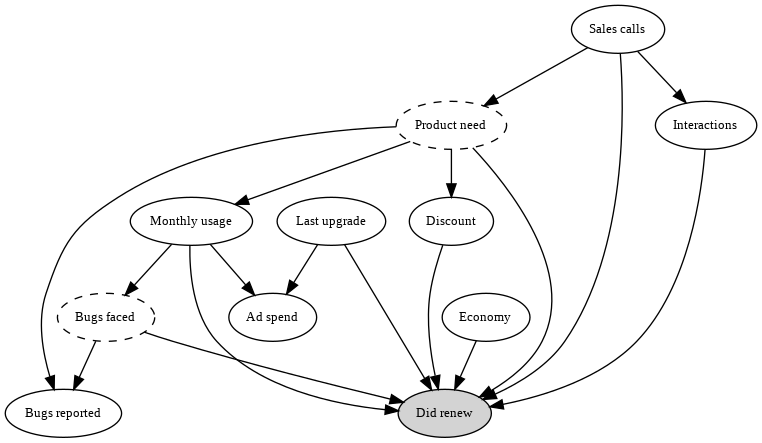

In [2]:
names = [
    "Bugs reported",
    "Monthly usage",
    "Sales calls",
    "Economy",
    "Discount",
    "Last upgrade",
    "Ad spend",
    "Interactions",
]
g = graphviz.Digraph(format="png")
for name in names:
    g.node(name, fontsize="10")
g.node("Product need", style="dashed", fontsize="10")
g.node("Bugs faced", style="dashed", fontsize="10")
g.node("Did renew", style="filled", fontsize="10")

g.edge("Product need", "Did renew")
g.edge("Product need", "Discount")
g.edge("Product need", "Bugs reported")
g.edge("Product need", "Monthly usage")
g.edge("Discount", "Did renew")
g.edge("Monthly usage", "Bugs faced")
g.edge("Monthly usage", "Did renew")
g.edge("Monthly usage", "Ad spend")
g.edge("Economy", "Did renew")
g.edge("Sales calls", "Did renew")
g.edge("Sales calls", "Product need")
g.edge("Sales calls", "Interactions")
g.edge("Interactions", "Did renew")
g.edge("Bugs faced", "Did renew")
g.edge("Bugs faced", "Bugs reported")
g.edge("Last upgrade", "Did renew")
g.edge("Last upgrade", "Ad spend")

display(Image(g.pipe(format='png')))

The DAG provides a model that tells us how the variables are related to each other and the "causal flow" between variables.

The dashed nodes indicate *latent* (unobserved) variables.

We see for example that `Bugs faced` impacts `Bugs reported` and `Did renew` but that there is no direct impact of `Bugs reported` on `Did renew`.

Suppose we did not know there was no direct effect of `Ad spend` on `Did renew` and thus wanted to try to learn this effect. Let's look at our DAG to see how we might do this.

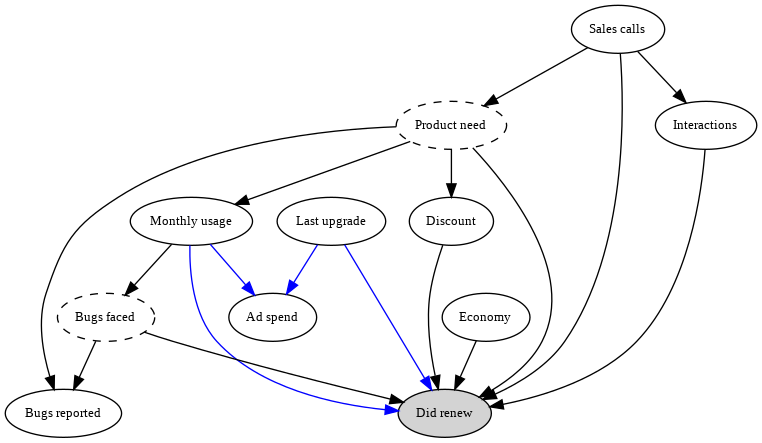

In [3]:
names = [
    "Bugs reported",
    "Monthly usage",
    "Sales calls",
    "Economy",
    "Discount",
    "Last upgrade",
    "Ad spend",
    "Interactions",
]

g = graphviz.Digraph(format="png")  # Set output format to PNG

for name in names:
    g.node(name, fontsize="10")

g.node("Product need", style="dashed", fontsize="10")
g.node("Bugs faced", style="dashed", fontsize="10")
g.node("Did renew", style="filled", fontsize="10")

g.edge("Product need", "Did renew")
g.edge("Product need", "Discount")
g.edge("Product need", "Bugs reported")
g.edge("Product need", "Monthly usage")
g.edge("Discount", "Did renew")
g.edge("Monthly usage", "Bugs faced")
g.edge("Monthly usage", "Did renew", color="blue")
g.edge("Monthly usage", "Ad spend", color="blue")
g.edge("Economy", "Did renew")
g.edge("Sales calls", "Did renew")
g.edge("Sales calls", "Product need")
g.edge("Sales calls", "Interactions")
g.edge("Interactions", "Did renew")
g.edge("Bugs faced", "Did renew")
g.edge("Bugs faced", "Bugs reported")
g.edge("Last upgrade", "Did renew", color="blue")
g.edge("Last upgrade", "Ad spend", color="blue")

# Render and display the PNG directly
display(Image(g.pipe(format='png')))


Looking at our DAG, we can see that we observe all *confounds* between `Ad spend` and `Did renew`. We can thus learn the causal effect of `Ad spend` on `Did renew` by *controlling* for the confounds -- `Monthly usage` and `Last upgrade`.

Suppose we wanted to learn the causal effect of `Discount` on `Did renew`. We can again look at our DAG.

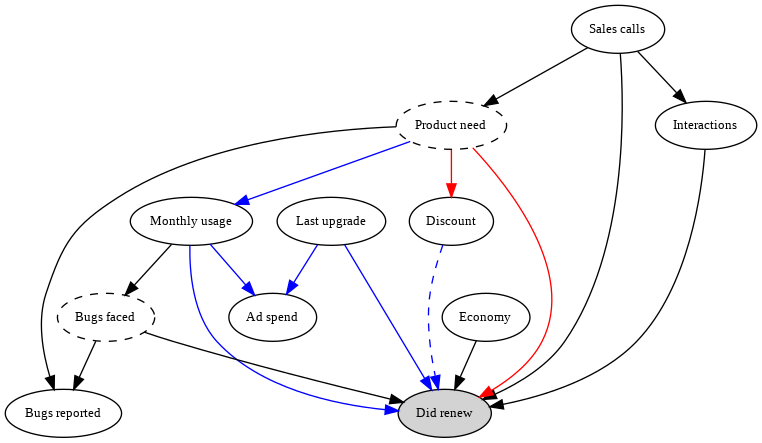

In [4]:
names = [
    "Bugs reported",
    "Monthly usage",
    "Sales calls",
    "Economy",
    "Discount",
    "Last upgrade",
    "Ad spend",
    "Interactions",
]

g = graphviz.Digraph(format="png")  # Set output format to PNG

for name in names:
    g.node(name, fontsize="10")

g.node("Product need", style="dashed", fontsize="10")
g.node("Bugs faced", style="dashed", fontsize="10")
g.node("Did renew", style="filled", fontsize="10")

g.edge("Product need", "Did renew", color="red")
g.edge("Product need", "Discount", color="red")
g.edge("Product need", "Bugs reported")
g.edge("Product need", "Monthly usage", color="blue")
g.edge("Discount", "Did renew", style="dashed", color="blue")
g.edge("Monthly usage", "Bugs faced")
g.edge("Monthly usage", "Did renew", color="blue")
g.edge("Monthly usage", "Ad spend", color="blue")
g.edge("Economy", "Did renew")
g.edge("Sales calls", "Did renew")
g.edge("Sales calls", "Product need")
g.edge("Sales calls", "Interactions")
g.edge("Interactions", "Did renew")
g.edge("Bugs faced", "Did renew")
g.edge("Bugs faced", "Bugs reported")
g.edge("Last upgrade", "Did renew", color="blue")
g.edge("Last upgrade", "Ad spend", color="blue")

# Render and display the PNG directly
display(Image(g.pipe(format='png')))


# Estimate the causal effect of Ad Spend

Let's now estimate a causal effect of `Ad Spend` on `Did Renew`. From the DAG, we see that we need to control for `Monthly Usage` and `Last Upgrade` to learn this effect. We will focus on a simple summary effect captured by a slope coefficient.

To learn a slope coefficient, summarizing the effect of causally intervening in the system and changing `Ad Spend` by one unit, we need to learn the part of `Ad Spend` that is not predicted by the confounds and the part of `Did Renew` that is not predicted by the confounds. That is, we need to learn the prediction errors/residuals from the problem of trying to predict `Did Renew` with `Monthly Usage` and `Last Upgrade` and of trying to predict `Ad Spend` with `Monthly Usage` and `Last Upgrade`.

These are simple prediction tasks, and ML is well-suited to building these prediction models.

As with any other prediction context, overfitting can have real impacts, so we want to set up our learning structure to help alleviate this concern. To do that, we employ *cross-fitting*:



1.   Divide the sample into k = 1,...,K subsamples
2.   For k = 1,...,K


*   Drop subsample k from the data
*   Use the remaining subsamples to learn prediction rules $\hat{g}_{k,Did Renew}(Monthly Usage, Last Upgrade)$ and $\hat{g}_{k,Ad Spend}(Monthly Usage, Last Upgrade)$
* Use $\hat{g}_{k,Did Renew}(Monthly Usage, Last Upgrade)$ and $\hat{g}_{k,Ad Spend}(Monthly Usage, Last Upgrade)$ and the data from subsample k to form prediction for `Did Renew` and `Ad Spend` in subsample k. Save the residuals.

3.  Stack the residuals from each subsample in step 2 and run the regression of the residual for `Did Renew` on the residual for `Ad Spend`

Let's look at how this works in our example data.

# Functions for Example

The example makes use of artificial data generated to resemble a simple verion of real data one might see in a customer retention setting.

The data are generated in the function `generator`.

We first generate observed predictor variables along with a couple of related unobserved variables.



*   `Sales Calls` (observed): Number of sales calls to the customer
*   `Interactions` (observed): Total number of interactions with the customer
*   `Economy` (observed): State of the customer's regional economy, normalized to the unit interval
*   `Last upgrade` (observed): Time since last upgrade
*   `Product need` (unobserved): How much the customer perceives that they need the product
*   `Discount` (observed): Fractional discount offered to the customer upon renewing
*   `Monthly Usage` (observed): Fraction of days customer used the product over the last period
*   `Ad Spend` (observed): Ad money spent targeting user
*   `Bugs Faced` (unobserved): How many bugs the customer actually experiences
*   `Bugs Reported` (observed): How many bugs the customer reports

We then generate the outcome variable as a binary variable where the probablity the outcome = 1 is a simple logistic function of the generated variables.

The function `user_retention_dataset()` generates the observed variables.

Finally, we will use boosted trees to form our prediction model. We set the parameters in the function `fit_xgboost`.



In [5]:
class FixableDataFrame(pd.DataFrame):
    """Helper class for manipulating generative models."""

    def __init__(self, *args, fixed={}, **kwargs):
        self.__dict__["__fixed_var_dictionary"] = fixed
        super().__init__(*args, **kwargs)

    def __setitem__(self, key, value):
        out = super().__setitem__(key, value)
        if isinstance(key, str) and key in self.__dict__["__fixed_var_dictionary"]:
            out = super().__setitem__(key, self.__dict__["__fixed_var_dictionary"][key])
        return out


# generate the data
def generator(n, fixed={}, seed=0):
    """The generative model for our subscriber retention example."""
    if seed is not None:
        np.random.seed(seed)
    X = FixableDataFrame(fixed=fixed)

    # the number of sales calls made to this customer
    X["Sales calls"] = np.random.uniform(0, 4, size=(n,)).round()

    # the total number of interactions with the customer
    X["Interactions"] = X["Sales calls"] + np.random.poisson(0.2, size=(n,))

    # the health of the regional economy this customer is a part of
    X["Economy"] = np.random.uniform(0, 1, size=(n,))

    # the time since the last product upgrade when this customer came up for renewal
    X["Last upgrade"] = np.random.uniform(0, 20, size=(n,))

    # how much the user perceives that they need the product
    X["Product need"] = X["Sales calls"] * 0.1 + np.random.normal(0, 1, size=(n,))

    # the fractional discount offered to this customer upon renewal
    X["Discount"] = ((1 - scipy.special.expit(X["Product need"])) * 0.5 + 0.5 * np.random.uniform(0, 1, size=(n,))) / 2

    # What percent of the days in the last period was the user actively using the product
    X["Monthly usage"] = scipy.special.expit(X["Product need"] * 0.3 + np.random.normal(0, 1, size=(n,)))

    # how much ad money we spent per user targeted at this user (or a group this user is in)
    X["Ad spend"] = (
        X["Monthly usage"] * np.random.uniform(0.99, 0.9, size=(n,)) + (X["Last upgrade"] < 1) + (X["Last upgrade"] < 2)
    )

    # how many bugs did this user encounter in the since their last renewal
    X["Bugs faced"] = np.array([np.random.poisson(v * 2) for v in X["Monthly usage"]])

    # how many bugs did the user report?
    X["Bugs reported"] = (X["Bugs faced"] * scipy.special.expit(X["Product need"])).round()

    # did the user renew?
    X["Did renew"] = scipy.special.expit(
        7
        * (
            0.18 * X["Product need"]
            + 0.08 * X["Monthly usage"]
            + 0.1 * X["Economy"]
            + 0.05 * X["Discount"]
            + 0.05 * np.random.normal(0, 1, size=(n,))
            + 0.05 * (1 - X["Bugs faced"] / 20)
            + 0.005 * X["Sales calls"]
            + 0.015 * X["Interactions"]
            + 0.1 / (X["Last upgrade"] / 4 + 0.25)
            + X["Ad spend"] * 0.0
            - 0.45
        )
    )

    X["Did renew"] = scipy.stats.bernoulli.rvs(X["Did renew"])

    return X


def user_retention_dataset():
    """The observed data for model training."""
    n = 10000
    X_full = generator(n)
    y = X_full["Did renew"]
    X = X_full.drop(["Did renew", "Product need", "Bugs faced"], axis=1)
    return X, y


def fit_xgboost(X, y, loss="logistic"):
    """Train an XGBoost model with early stopping."""
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y)
    dtrain = xgboost.DMatrix(X_train, label=y_train)
    dtest = xgboost.DMatrix(X_test, label=y_test)

    params = {
        "eta": 0.001,
        "subsample": 0.5,
        "max_depth": 2,
    }

    if loss == "logistic":
        params["objective"] = "reg:logistic"
    elif loss == "squared_error":
        params["objective"] = "reg:squarederror"
    else:
        raise ValueError("Invalid loss function. Choose 'logistic' or 'squared_error'.")

    model = xgboost.train(
        params,
        dtrain,
        num_boost_round=200000,
        evals=((dtest, "test"),),
        early_stopping_rounds=20,
        verbose_eval=False,
    )

    return model

In [6]:
# Generate data
X, y = user_retention_dataset()

Ad = X["Ad spend"]
Xc = X.drop(["Ad spend"], axis=1)

In [7]:
# Need to make folds just like for cross-validation
cv = KFold(n_splits=5, shuffle = True, random_state = 220)

# Store residuals
residuals_y = []
residuals_Ad = []

# Loop through folds
for train_idx, test_idx in cv.split(Xc):
    # Split data
    X_train, X_test = Xc.iloc[train_idx], Xc.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    Ad_train, Ad_test = Ad.iloc[train_idx], Ad.iloc[test_idx]

    # Train models
    model_y = fit_xgboost(X_train, y_train, loss="logistic")
    model_Ad = fit_xgboost(X_train, Ad_train, loss="squared_error")

    # Predict on the test set
    y_pred = model_y.predict(xgboost.DMatrix(X_test))  # Predicted probability
    Ad_pred = model_Ad.predict(xgboost.DMatrix(X_test))

    # Compute residuals
    residuals_y.extend(y_test - y_pred)
    residuals_Ad.extend(Ad_test - Ad_pred)

# Convert residuals to NumPy array
residuals_y = np.array(residuals_y)
residuals_Ad = np.array(residuals_Ad)

# Regression of residuals_y onto residuals_Ad with robust standard errors (HC3)
X_resid = sm.add_constant(residuals_Ad)
model = sm.OLS(residuals_y, X_resid).fit(cov_type='HC3')

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.104
Date:                Thu, 20 Feb 2025   Prob (F-statistic):              0.293
Time:                        18:50:47   Log-Likelihood:                -5731.2
No. Observations:               10000   AIC:                         1.147e+04
Df Residuals:                    9998   BIC:                         1.148e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0007      0.004     -0.172      0.8